# Studio 2 — One problem, two methods 🪑🪚

**OPIM 5641 · Business Decision Modeling · Dr. Dave Wanik, UConn**

Tonight we take **one** linear program and solve it **two completely different ways**:

1. **Brute force** — let the computer try every production plan and keep the best one.
2. **The graphical method** — draw the constraints, shade what's impossible, check the corners.

Same problem, same answer, wildly different amounts of work. That contrast is the point: when you
meet a problem too big to draw, you'll know what the picture *would* have looked like.

---

### Flair's Furniture (the example from the M2.2 videos)

Flair Furniture makes inexpensive **tables** and **chairs**. Both go through carpentry and painting:

| | carpentry hours | painting hours | profit each |
|---|---|---|---|
| a table | 3 | 2 | $7 |
| a chair | 4 | 1 | $5 |
| **available this month** | **2,400 hrs** | **1,000 hrs** | |

Marketing adds two rules: **no more than 450 chairs** (there's already a pile of them), and
**at least 100 tables** (inventory is low).

**The question:** how many tables and chairs should Flair make this month to earn the most profit?

## 1 · Name the pieces

Same three parts, every time — you just did this on paper.

**Decision variables** (what we choose): $T$ = tables to make, $C$ = chairs to make.

**Objective function** (what we maximize):

$$\text{Max } Z = 7T + 5C$$

The **7** and **5** are the *objective function coefficients* — the profit each unit contributes.

**Constraints** (the rules):

$$3T + 4C \le 2400 \quad \text{(carpentry hours)}$$
$$2T + 1C \le 1000 \quad \text{(painting hours)}$$
$$C \le 450 \quad \text{(marketing: chair limit)}$$
$$T \ge 100 \quad \text{(marketing: table minimum)}$$
$$T, C \ge 0 \quad \text{(non-negativity — you can't make }-4\text{ chairs)}$$

## 2 · Soft-code the data

**Never bury numbers inside your loops.** Put them in dictionaries up top, then the search below
reads like the formulation. Change a price here and everything downstream updates — that's the
difference between a model and a one-off script.

In [1]:
import numpy as np
import pandas as pd
from pylab import *   # for graphing, same as the M2.2 notebooks

# products
products = ["tables", "chairs"]

# hours each product needs in each department
carpentry = {
    "tables" : 3,
    "chairs" : 4
}
painting = {
    "tables" : 2,
    "chairs" : 1
}

# hours available this month
total_time = {
    "carpentry" : 2400,
    "painting"  : 1000
}

# profit contribution per unit  <- the objective function coefficients
profit = {
    "tables" : 7,
    "chairs" : 5
}

# what marketing insists on
limits = {
    "max_chairs" : 450,
    "min_tables" : 100
}

## 3 · Method 1: brute force

The plan: a **nested for loop** over every whole number of tables and chairs — the same loop shape
you traced by hand in the math check, with something useful inside.

How big is the search? Tables can't exceed 800 (that's all the carpentry hours), and chairs can't
exceed 600. **Predict the number of plans before you run the next cell.**

In [2]:
801 * 601   # 481,401 combinations - 0 through 800 tables and 0 through 600 chairs, inclusive!

481401

In [3]:
# the clean search: nested loops, clear bounds, ONE big if, print the answer
best_profit = 0
best_tables = 0
best_chairs = 0
plans_checked = 0

for tables in np.arange(0, 801, 1):        # 0 through 800 inclusive - making NONE is a valid plan!
    for chairs in np.arange(0, 601, 1):
        plans_checked = plans_checked + 1

        carpentry_hours = carpentry["tables"] * tables + carpentry["chairs"] * chairs
        painting_hours  = painting["tables"]  * tables + painting["chairs"]  * chairs

        # ONE big if - every constraint in a single readable condition
        if (carpentry_hours <= total_time["carpentry"] and
            painting_hours  <= total_time["painting"] and
            chairs <= limits["max_chairs"] and
            tables >= limits["min_tables"]):

            current_profit = profit["tables"] * tables + profit["chairs"] * chairs
            if current_profit > best_profit:
                best_profit = current_profit
                best_tables = tables
                best_chairs = chairs

print("Plans checked:", plans_checked)
print("Maximum profit:", best_profit)
print("tables:", best_tables)
print("chairs:", best_chairs)

Plans checked: 481401
Maximum profit: 4040
tables: 320
chairs: 360


Brute force is **honest**: it tried everything, so that answer is certainly the best one. It is
also enormously wasteful — most of those plans broke a rule, and it never once looked at the *shape*
of the problem. Hold that thought.

## 4 · Method 2: the graphical method

With two decision variables we can draw the entire problem. Each constraint becomes a line; to plot
it, set one variable to zero and read off the two intercepts:

* $3T + 4C = 2400$ → when $T=0$, $C=600$; when $C=0$, $T=800$
* $2T + 1C = 1000$ → when $T=0$, $C=1000$; when $C=0$, $T=500$
* $C = 450$ → a horizontal line
* $T = 100$ → a vertical line

Tables go on the x-axis, chairs on the y-axis. The **shaded** areas are what each constraint
forbids, so the white area left over is where the legal plans live.

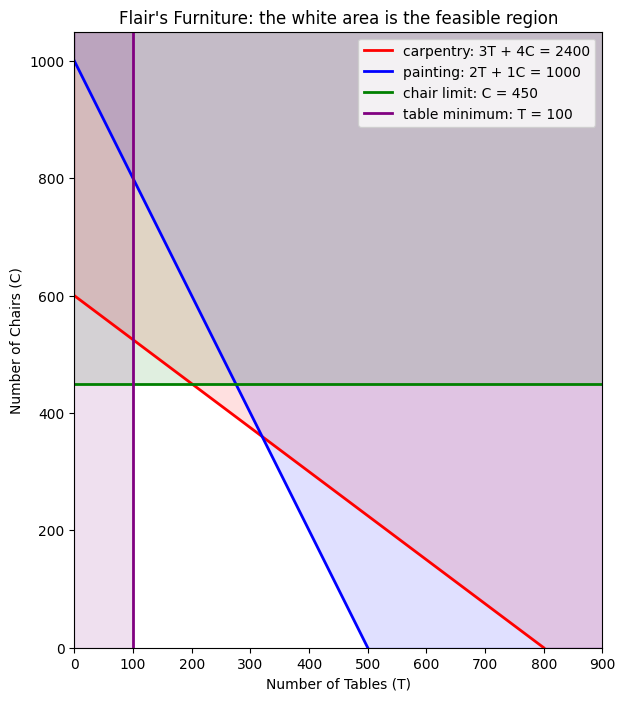

In [4]:
figure(figsize=(8, 8))
subplot(111, aspect='equal')
axis([0, 900, 0, 1050])
xlabel('Number of Tables (T)')
ylabel('Number of Chairs (C)')

# Carpentry Constraint: 3T + 4C <= 2400
plot([0, 800], [600, 0], 'r', lw=2, label='carpentry: 3T + 4C = 2400')   # label goes ON THE LINE
fill_between([0, 800, 900],      # x
             [600, 0, 0],        # the line
             [1050, 1050, 1050], # everything above it is infeasible
             color='red', alpha=0.12)

# Painting Constraint: 2T + 1C <= 1000
plot([0, 500], [1000, 0], 'b', lw=2, label='painting: 2T + 1C = 1000')
fill_between([0, 500, 900],
             [1000, 0, 0],
             [1050, 1050, 1050],
             color='blue', alpha=0.12)

# Chair limit: C <= 450  (horizontal line, shade above)
plot([0, 900], [450, 450], 'g', lw=2, label='chair limit: C = 450')
fill_between([0, 900], [450, 450], [1050, 1050], color='green', alpha=0.12)

# Table minimum: T >= 100  (vertical line, shade to the left)
plot([100, 100], [0, 1050], 'purple', lw=2, label='table minimum: T = 100')
axvspan(0, 100, color='purple', alpha=0.12)

legend(loc='upper right')
title("Flair's Furniture: the white area is the feasible region")
savefig('fig_feasible_region.png')
show()

### Plug and chug

Any point in the white region is a legal plan, but they are not equally good. Try a couple the way
you would in a meeting:

$Z = 7T + 5C$ at $(T=200, C=100)$ → $7(200) + 5(100) = 1900$
$Z = 7T + 5C$ at $(T=150, C=300)$ → $7(150) + 5(300) = 2550$

Better, but is it the best? There are infinitely many points in that region — we need the trick.

### The corner point property

**An optimal solution to an LP always sits at a corner of the feasible region.** Corners are where
constraint lines cross, so instead of half a million plans we check **five points**.

Two of them are worth solving by hand:
- carpentry meets painting: solve $3T + 4C = 2400$ with $2T + 1C = 1000$ → $T = 320,\ C = 360$
- carpentry meets the chair limit: $C = 450$, so $3T + 1800 = 2400$ → $T = 200$

In [5]:
corners = [(100, 0), (100, 450), (200, 450), (320, 360), (500, 0)]

results = []
for tables, chairs in corners:
    z = profit["tables"] * tables + profit["chairs"] * chairs
    results.append({"tables": tables, "chairs": chairs, "profit": z})

pd.DataFrame(results).sort_values("profit", ascending=False)

,tables,chairs,profit
3,320,360,4040
2,200,450,3650
4,500,0,3500
1,100,450,2950
0,100,0,700


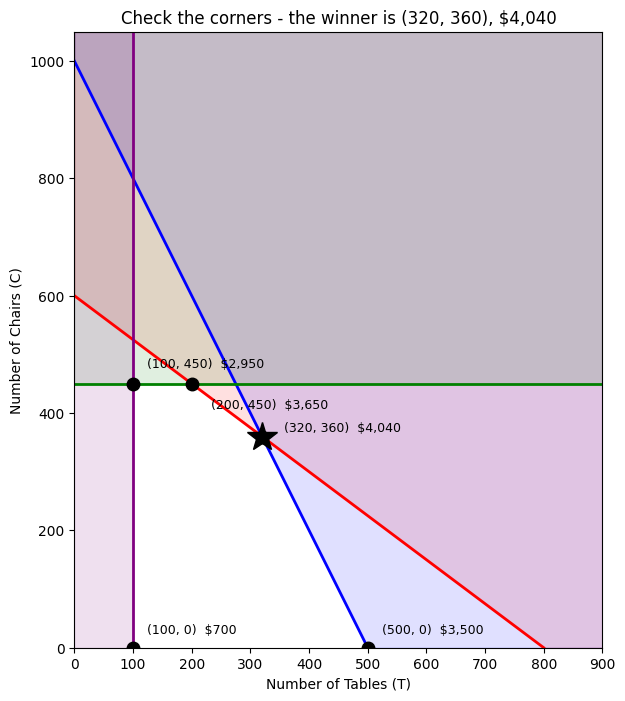

In [6]:
figure(figsize=(8, 8))
subplot(111, aspect='equal')
axis([0, 900, 0, 1050])
xlabel('Number of Tables (T)')
ylabel('Number of Chairs (C)')

plot([0, 800], [600, 0], 'r', lw=2)
fill_between([0, 800, 900], [600, 0, 0], [1050, 1050, 1050], color='red', alpha=0.12)
plot([0, 500], [1000, 0], 'b', lw=2)
fill_between([0, 500, 900], [1000, 0, 0], [1050, 1050, 1050], color='blue', alpha=0.12)
plot([0, 900], [450, 450], 'g', lw=2)
fill_between([0, 900], [450, 450], [1050, 1050], color='green', alpha=0.12)
plot([100, 100], [0, 1050], 'purple', lw=2)
axvspan(0, 100, color='purple', alpha=0.12)

nudge = {(100, 0): (10, 10), (100, 450): (10, 12), (200, 450): (14, -18),
         (320, 360): (16, 4), (500, 0): (10, 10)}
for tables, chairs in corners:
    z = profit["tables"] * tables + profit["chairs"] * chairs
    plot(tables, chairs, 'ko', markersize=9)
    annotate(f'({tables}, {chairs})  ${z:,}', (tables, chairs), fontsize=9,
             xytext=nudge[(tables, chairs)], textcoords='offset points')

plot(320, 360, 'k*', markersize=22)
title('Check the corners - the winner is (320, 360), $4,040')
savefig('fig_corners.png')
show()

## 5 · Two methods, one answer

| method | plans examined | answer |
|---|---|---|
| brute force | 481,401 | 320 tables, 360 chairs, **$4,040** |
| graphical | 5 corners | 320 tables, 360 chairs, **$4,040** |

The graph didn't get lucky. The corner point property **guarantees** the optimum is at a corner, so
those five points were the only ones that could ever win.

**Talk with your partner:**
1. Brute force needed no insight but did enormous work. The graph needed one idea and almost none.
   Which would you rather explain to a manager?
2. Both constraints are tight at the winner (all 2,400 carpentry hours and all 1,000 painting hours
   are used). What would one more carpentry hour be worth to Flair?
3. The graphical method only works with **two** decision variables. What would you do with ten
   products? (That question is exactly why the Simplex method exists — it's next.)

## 6 · Save your work 📝

**File → Save a copy in GitHub → your `opim5641-work` repo**, along with the two figures
(`fig_feasible_region.png`, `fig_corners.png`).

Before you close the laptop, make sure you can say in your own words:
1. What a **decision variable** is, and what the **objective function coefficients** mean.
2. Why soft-coding the numbers into dictionaries beats typing them into the loop.
3. Why the best plan is always at a **corner**.